<a href="https://colab.research.google.com/github/code101-wq/Beyond-Keywords-Vector-Search-Engine-from-Scratch/blob/main/RAG_implementation_with_vector_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.8/739.8 kB 20.5 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.7.0
    Uninstalling sentence-transformers-5.7.0:
      Successfully uninstalled sentence-transformers-5.7.0


In [2]:
"""
Created on Tue Sep  1 14:03:17 2026

@author: user
"""
import numpy as np
np.random.seed(42)
from sentence_transformers import SentenceTransformer

products = [
    "Wireless noise-cancelling headphones with 30-hour battery",
    "Bluetooth speaker with waterproof design",
    "USB-C hub with 7 ports and power delivery",
    "4K HDMI cable 6ft braided",
    "Mechanical keyboard with RGB backlight",
    "Men's slim-fit chino pants navy blue",
    "Women's merino wool turtleneck sweater",
    "Unisex running jacket lightweight windbreaker",
    "Leather chelsea boots for men",
    "Organic cotton crew neck t-shirt",
    "Solid oak dinning table seats 6",
    "Ergonomic mesh office chair lumbar support",
    "Linen sofa 3-seater natural beige",
    "Bamboo bookshelf 5-tier adjustable",
    "Memory foam mattress queen size medium firm"
]


In [3]:
# transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generating dense vector representations
embeddings = model.encode(products)

print(f"Embeddings shape: {embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings shape: (15, 384)


In [4]:
### Building the Index

def normalize(vectors: np.ndarray) -> np.ndarray:
    """L2.-normalize each row vector. """
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    # Prevent division by 0
    norms = np.where(norms == 0, 1e-10, norms)
    return vectors / norms

class VectorIndex:
    def __init__(self):
        self.vectors = None
        self.labels  = None

    def add(self, vectors: np.ndarray, labels: list):
        self.vectors = normalize(vectors)
        self.labels  = labels
        print(f"Indexed {len(labels)} items with {vectors.shape[1]}-dimensional embeddings.:")

    def search(self, query_vector: np.ndarray, top_k: int = 3):
        query_norm = normalize(query_vector.reshape(1, -1))
        # Perform Cosine Similarity below, the dot product of normalized vectors
        scores = self.vectors @ query_norm.T # shape: (n_items, 1)
        scores = scores.flatten()

        # Get the top-k indices sorted by descending score
        top_indices = np.argsort(scores)[::-1][:top_k]
        return [(self.labels[i], float(scores[i])) for i in top_indices]

index = VectorIndex()
index.add(embeddings, products)

Indexed 15 items with 384-dimensional embeddings.:


In [5]:
# Here the querries are constructed from the initialized document

queries = {
    "audio equipment": model.encode("audio equipment"),
    "casual wear"    : model.encode("casual wear"),
    "home furniture" : model.encode("home furniture")
    }
for query_name, q_vec in queries.items():
    print(f"\nQuery: '{query_name}'")
    results = index.search(q_vec, top_k=3)
    for rank, (label, score) in enumerate(results, 1):
        print(f"  {rank}. [{score:.4f}] {label}")



Query: 'audio equipment'
  1. [0.2831] Wireless noise-cancelling headphones with 30-hour battery
  2. [0.2666] 4K HDMI cable 6ft braided
  3. [0.1880] Bluetooth speaker with waterproof design

Query: 'casual wear'
  1. [0.4048] Men's slim-fit chino pants navy blue
  2. [0.4043] Unisex running jacket lightweight windbreaker
  3. [0.3772] Leather chelsea boots for men

Query: 'home furniture'
  1. [0.4669] Linen sofa 3-seater natural beige
  2. [0.4305] Solid oak dinning table seats 6
  3. [0.2742] Bamboo bookshelf 5-tier adjustable


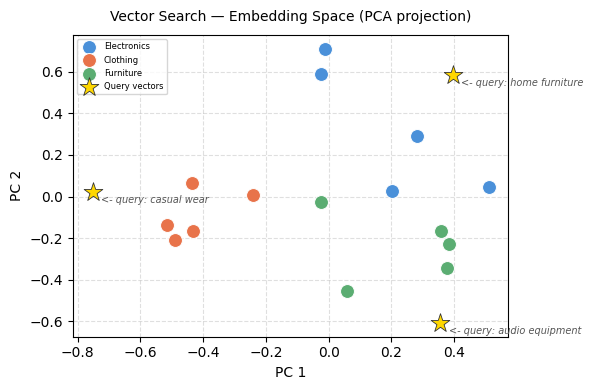

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
def pca_2d(X: np.ndarray) -> np.ndarray:

    if not isinstance(X, np.ndarray):
        X = np.array(X)

    if X.ndim != 2: # check dimensiton of input matrix
        raise ValueError(f"Input must be a 2D matrix of shape (samples, dimensions), got {X.ndim}D.")

    n_samples, n_features = X.shape
    if n_samples < 2 or n_features < 2:
        raise ValueError("Data must have at least 2 samples and 2 features to reduce to 2D.")

    # Initialize the PCA model with 2 principal components
    pca = PCA(n_components=2)

    # Fit the model (learn the directions of maximum variance) and transform the data onto 2 directions
    X_reduced = pca.fit_transform(X)

    return X_reduced

projected = pca_2d(embeddings)
fig, ax = plt.subplots(figsize=(6, 4))

# Define cluster metadata to plot categories with native labels
clusters = [
    ("Electronics", projected[0:5],   "#4A90D9"),
    ("Clothing",    projected[5:10],  "#E8734A"),
    ("Furniture",   projected[10:15], "#5BAD72")
]

for label, points, color in clusters:
    ax.scatter(points[:, 0], points[:, 1], c=color, s=100,
               label=label, edgecolor="white", linewidths=0.7, zorder=3)

# Plot query projections (label only the first query so legend lists it once)
q_projected = pca_2d(
    np.vstack(list(queries.values())) - embeddings.mean(axis=0)
)

for idx, ((qname, _), (qx, qy)) in enumerate(zip(queries.items(), q_projected)):
    ax.scatter(qx, qy, marker="*", s=200, color="gold", edgecolors="#333",
               linewidths=0.6, zorder=4,
               label="Query vectors" if idx == 0 else "")
    ax.annotate(f"<- query: {qname}", (qx, qy), textcoords="offset points",
                xytext=(6, -8), fontsize=7, color="#555555", style="italic")

# Automatic legend handles everything cleanly
ax.legend(loc="upper left", fontsize=6)
ax.set_title("Vector Search — Embedding Space (PCA projection)", fontsize=10, pad=10)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("embedding_space_queries_only.png", dpi=150)
plt.show()

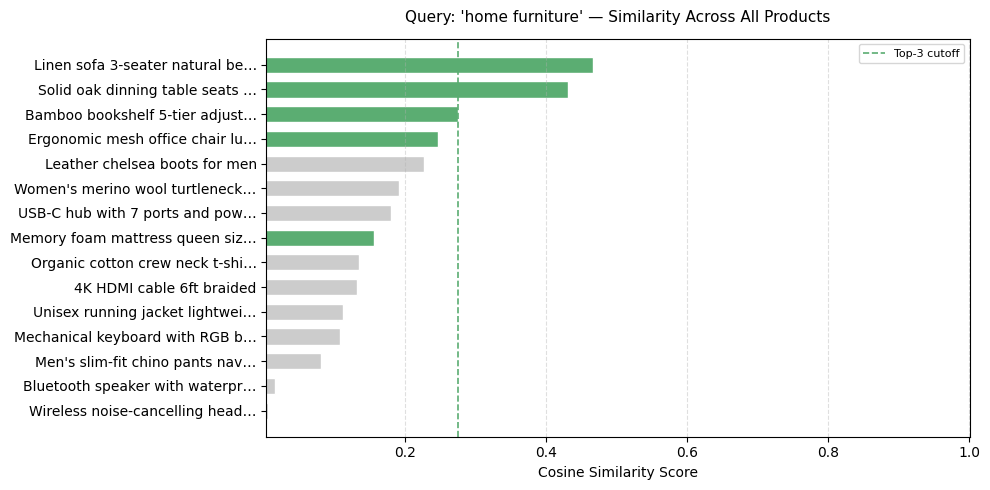

In [7]:
### Visualizing the Similarity Score Distribution

q_vec_furniture = queries["home furniture"]
q_norm_furniture = normalize(q_vec_furniture.reshape(1, -1))
all_scores_furniture = (index.vectors @ q_norm_furniture.T).flatten()

sorted_idx_furniture = np.argsort(all_scores_furniture)[::-1]
sorted_scores_furniture = all_scores_furniture[sorted_idx_furniture]
sorted_labels_furniture = [products[i][:30] + "…" if len(products[i]) > 30
                           else products[i] for i in sorted_idx_furniture]

# green for furniture items, gray for others
bar_colors_furniture = []
for i in sorted_idx_furniture:
    if i >= 10 and i <= 14:
        bar_colors_furniture.append("#5BAD72")
    else:
        bar_colors_furniture.append("#cccccc")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_labels_furniture[::-1], sorted_scores_furniture[::-1],
               color=bar_colors_furniture[::-1], edgecolor="white", height=0.65)

ax.axvline(sorted_scores_furniture[2], color="#5BAD72", linestyle="--",
           linewidth=1.2, label="Top-3 cutoff")
ax.set_xlim(sorted_scores_furniture.min() - 0.002, 1.001)
ax.set_xlabel("Cosine Similarity Score")
ax.set_title("Query: 'home furniture' — Similarity Across All Products", fontsize=11, pad=12)
ax.legend(fontsize=8)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("score_distribution_furniture.png", dpi=150)
plt.show()


In [13]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
private_docs = [
 "The Lojules LLM backbone is built of Njikwa transformer arcitecture.",
 "Lojules LLM has a context size of 1,005,000 tokens.",
 "Lojules LLM transformer concept is based on fractal analysis.",
 "Fractal analysis makes Lojules LLM a foundation for AGI."]
doc_embeddings = model.encode(private_docs)
index = VectorIndex()
index.add(doc_embeddings, private_docs)
m_name = "google/flan-t5-base"
llm_tokenizer = AutoTokenizer.from_pretrained(m_name)
llm_model = AutoModelForSeq2SeqLM.from_pretrained(m_name)
def generate_text(prompt: str) -> str:
    inputs=llm_tokenizer(prompt, return_tensors="pt")
    outputs=llm_model.generate(**inputs, max_new_tokens=60)
    return llm_tokenizer.decode(outputs[0],   skip_special_tokens=True)

user_query = "What is the backbone of the Lojules LLM?"
#  Test A: without RAG
prompt_without_rag = f"Answer this question: {user_query}"
raw_llm_response = generate_text(prompt_without_rag)
# Test B: with RAG
query_embedding = model.encode([user_query])
search_results = index.search(query_embedding, top_k=2)
retrieved_context = "\n".join([f"- {text}" for text, score in search_results])
prompt_with_rag = f"""Answer the question using ONLY the provided context.
Context:{retrieved_context} Question: {user_query}"""
rag_llm_response = generate_text(prompt_with_rag)
print("RESPONSES!!!!")
print("\n RESPONSE WITHOUT RAG:")
print(" The response without RAG is:")
print(f"{raw_llm_response}")
print("\n2. RESPONSE WITH RAG:")
print(" The response with RAG is:")
print(f"{rag_llm_response}")



Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


RESPONSES!!!!

 RESPONSE WITHOUT RAG:
 The response without RAG is:
the Lojules LLM

2. RESPONSE WITH RAG:
 The response with RAG is:
Njikwa transformer arcitecture
